In [3]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub



In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
dataset_path = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

image_root = dataset_path / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder:", image_root)
print("Image folder exists:", image_root.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [5]:
class_to_binary = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_to_binary.items():
    class_folder = image_root / class_name

    for image_path in sorted(class_folder.iterdir()):
        if image_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(image_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
print(df["label"].value_counts().sort_index())

Total images: 44000
label
0    12800
1    31200
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

development_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=SEED
)

development_df = development_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Development images:", len(development_df))
print(development_df["label"].value_counts().sort_index())

print("\nTest images:", len(test_df))
print(test_df["label"].value_counts().sort_index())

Development images: 37400
label
0    10880
1    26520
Name: count, dtype: int64

Test images: 6600
label
0    1920
1    4680
Name: count, dtype: int64


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_resize_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)

    return image, label


def create_dataset(dataframe, training=False, shuffle_seed=SEED):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(dataframe), 10000),
            seed=shuffle_seed,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_resize_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


test_dataset = create_dataset(test_df)

for images, labels in test_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

I0000 00:00:1787557649.258964      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


In [8]:
from sklearn.model_selection import StratifiedKFold

MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001
N_FOLDS = 5

cross_validator = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

for fold_number, (train_indices, validation_indices) in enumerate(
    cross_validator.split(
        development_df,
        development_df["label"]
    ),
    start=1
):
    fold_train = development_df.iloc[train_indices]
    fold_validation = development_df.iloc[validation_indices]

    print(
        f"Fold {fold_number}: "
        f"Training = {len(fold_train)}, "
        f"Validation = {len(fold_validation)}"
    )

Fold 1: Training = 29920, Validation = 7480
Fold 2: Training = 29920, Validation = 7480
Fold 3: Training = 29920, Validation = 7480
Fold 4: Training = 29920, Validation = 7480
Fold 5: Training = 29920, Validation = 7480


In [10]:
def build_resnet50(fold_seed):
    tf.keras.utils.set_random_seed(fold_seed)

    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomTranslation(0.05, 0.05)
    ])

    resnet_base = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    resnet_base.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = data_augmentation(inputs)
    x = tf.keras.applications.resnet50.preprocess_input(x)
    x = resnet_base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.30)(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = tf.keras.Model(
        inputs,
        outputs,
        name="ResNet50_Binary"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return modelimport gc
import time

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

fold_histories = {}
fold_results = []
fold_test_probabilities = []

print("Cross-validation storage initialized.")

In [11]:
import gc
import time

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

fold_histories = {}
fold_results = []
fold_test_probabilities = []

print("Cross-validation storage initialized.")

Cross-validation storage initialized.


In [12]:
for fold, (train_indices, validation_indices) in enumerate(
    cross_validator.split(
        development_df,
        development_df["label"]
    ),
    start=1
):
    print(f"\n{'=' * 20} FOLD {fold}/5 {'=' * 20}")

    fold_train_df = development_df.iloc[
        train_indices
    ].reset_index(drop=True)

    fold_validation_df = development_df.iloc[
        validation_indices
    ].reset_index(drop=True)

    train_dataset = create_dataset(
        fold_train_df,
        training=True,
        shuffle_seed=SEED + fold
    )

    validation_dataset = create_dataset(
        fold_validation_df
    )

    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=fold_train_df["label"]
    )

    fold_class_weights = {
        0: float(weights[0]),
        1: float(weights[1])
    }

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_resnet50(SEED + fold)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1
        )
    ]

    start_time = time.time()

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=MAX_EPOCHS,
        class_weight=fold_class_weights,
        callbacks=callbacks,
        verbose=1
    )

    training_minutes = (
        time.time() - start_time
    ) / 60

    fold_histories[fold] = pd.DataFrame(
        history.history
    )

    validation_probabilities = model.predict(
        validation_dataset,
        verbose=0
    ).ravel()

    validation_labels = fold_validation_df[
        "label"
    ].to_numpy()

    validation_predictions = (
        validation_probabilities >= 0.5
    ).astype(int)

    fold_results.append({
        "Fold": fold,
        "Epochs": len(history.history["loss"]),
        "Accuracy": accuracy_score(
            validation_labels,
            validation_predictions
        ),
        "Precision": precision_score(
            validation_labels,
            validation_predictions
        ),
        "Recall": recall_score(
            validation_labels,
            validation_predictions
        ),
        "F1-score": f1_score(
            validation_labels,
            validation_predictions
        ),
        "ROC-AUC": roc_auc_score(
            validation_labels,
            validation_probabilities
        ),
        "Training Minutes": training_minutes
    })

    fold_test_probabilities.append(
        model.predict(
            test_dataset,
            verbose=0
        ).ravel()
    )

    print(
        f"Fold {fold} completed in "
        f"{training_minutes:.2f} minutes"
    )


==================== FOLD 1/5 ====================
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 106s 102ms/step - accuracy: 0.6298 - loss: 0.6528 - val_accuracy: 0.7000 - val_loss: 0.5898 - learning_rate: 1.0000e-04
Epoch 2/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 89s 95ms/step - accuracy: 0.7193 - loss: 0.5596 - val_accuracy: 0.7257 - val_loss: 0.5533 - learning_rate: 1.0000e-04
Epoch 3/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 89s 95ms/step - accuracy: 0.7439 - loss: 0.5281 - val_accuracy: 0.7551 - val_loss: 0.5054 - learning_rate: 1.0000e-04
Epoch 4/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 88s 95ms/step - accuracy: 0.7519 - loss: 0.5146 - val_accuracy: 0.7443 - val_loss: 0.5146 - learning_rate: 1.0000e-04
Epoch 5/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7597 - loss: 0.5040
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
935/935 ━━━━━━━━━━━━━━━━━━━━ 90s 96ms/step - accuracy: 0.7601 - loss: 0.5026 - val_accuracy: 0.7374 

In [13]:
fold_results_df = pd.DataFrame(fold_results)

display(
    fold_results_df.round(4)
)

,Fold,Epochs,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Minutes
0,1,8,0.7551,0.8960,0.7406,0.8109,0.8510,12.1542
1,2,11,0.7444,0.9125,0.7074,0.7969,0.8646,16.4108
2,3,14,0.7380,0.9135,0.6965,0.7903,0.8633,20.8919
3,4,13,0.7326,0.9170,0.6850,0.7842,0.8669,19.2950
4,5,14,0.7516,0.9174,0.7140,0.8030,0.8674,20.9897


In [14]:
for fold, history_df in fold_histories.items():
    best_index = history_df["val_loss"].idxmin()

    fold_results_df.loc[
        fold_results_df["Fold"] == fold,
        "Training Loss"
    ] = history_df.loc[best_index, "loss"]

    fold_results_df.loc[
        fold_results_df["Fold"] == fold,
        "Training Accuracy"
    ] = history_df.loc[best_index, "accuracy"]

    fold_results_df.loc[
        fold_results_df["Fold"] == fold,
        "Validation Loss"
    ] = history_df.loc[best_index, "val_loss"]

    fold_results_df.loc[
        fold_results_df["Fold"] == fold,
        "Validation Accuracy"
    ] = history_df.loc[best_index, "val_accuracy"]

display(fold_results_df.round(4))

,Fold,Epochs,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Minutes,Training Loss,Training Accuracy,Validation Loss,Validation Accuracy
0,1,8,0.7551,0.8960,0.7406,0.8109,0.8510,12.1542,0.5281,0.7439,0.5054,0.7551
1,2,11,0.7444,0.9125,0.7074,0.7969,0.8646,16.4108,0.4938,0.7618,0.5099,0.7444
2,3,14,0.7380,0.9135,0.6965,0.7903,0.8633,20.8919,0.5005,0.7611,0.5238,0.7380
3,4,13,0.7326,0.9170,0.6850,0.7842,0.8669,19.2950,0.4856,0.7677,0.5234,0.7326
4,5,14,0.7516,0.9174,0.7140,0.8030,0.8674,20.9897,0.4958,0.7615,0.5092,0.7516


In [15]:
summary_columns = [
    "Training Loss",
    "Training Accuracy",
    "Validation Loss",
    "Validation Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

cv_summary = pd.DataFrame({
    "Mean": fold_results_df[summary_columns].mean(),
    "Standard Deviation": fold_results_df[summary_columns].std()
})

display(cv_summary.round(4))

,Mean,Standard Deviation
Training Loss,0.5007,0.0162
Training Accuracy,0.7592,0.0090
Validation Loss,0.5143,0.0086
Validation Accuracy,0.7443,0.0093
Precision,0.9112,0.0088
Recall,0.7087,0.0210
F1-score,0.7971,0.0105
ROC-AUC,0.8626,0.0067


In [16]:
test_probabilities_cv = np.mean(
    np.vstack(fold_test_probabilities),
    axis=0
)

test_predictions_cv = (
    test_probabilities_cv >= 0.5
).astype(int)

true_test_labels = test_df["label"].to_numpy()

print("Test images:", len(true_test_labels))
print("Ensemble predictions:", len(test_predictions_cv))

Test images: 6600
Ensemble predictions: 6600


In [17]:
from sklearn.metrics import log_loss, accuracy_score

test_loss_cv = log_loss(
    true_test_labels,
    test_probabilities_cv
)

test_accuracy_cv = accuracy_score(
    true_test_labels,
    test_predictions_cv
)

print("Test Loss:", round(test_loss_cv, 4))
print("Test Accuracy:", round(test_accuracy_cv, 4))

Test Loss: 0.5062
Test Accuracy: 0.7545


In [18]:
print("Precision:", round(
    precision_score(
        true_test_labels,
        test_predictions_cv
    ), 4
))

print("Recall:", round(
    recall_score(
        true_test_labels,
        test_predictions_cv
    ), 4
))

print("F1-score:", round(
    f1_score(
        true_test_labels,
        test_predictions_cv
    ), 4
))

print("ROC-AUC:", round(
    roc_auc_score(
        true_test_labels,
        test_probabilities_cv
    ), 4
))

Precision: 0.9144
Recall: 0.7214
F1-score: 0.8065
ROC-AUC: 0.8658


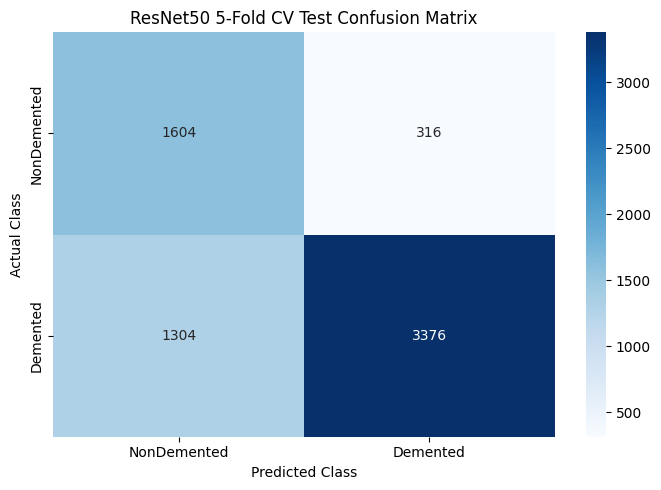

In [19]:
from sklearn.metrics import confusion_matrix

cm_cv = confusion_matrix(
    true_test_labels,
    test_predictions_cv
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_cv,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NonDemented", "Demented"],
    yticklabels=["NonDemented", "Demented"]
)

plt.title("ResNet50 5-Fold CV Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

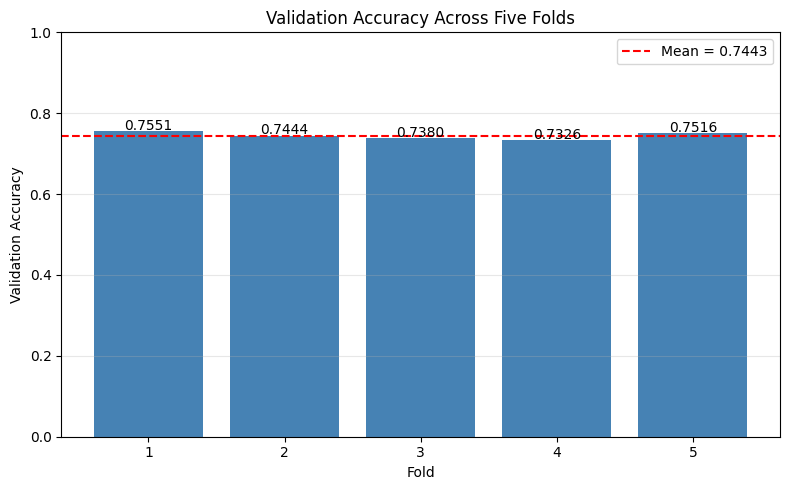

In [20]:
mean_accuracy = fold_results_df[
    "Validation Accuracy"
].mean()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    fold_results_df["Fold"],
    fold_results_df["Validation Accuracy"],
    color="steelblue"
)

plt.axhline(
    mean_accuracy,
    color="red",
    linestyle="--",
    label=f"Mean = {mean_accuracy:.4f}"
)

for bar, value in zip(
    bars,
    fold_results_df["Validation Accuracy"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.003,
        f"{value:.4f}",
        ha="center"
    )

plt.ylim(0, 1)
plt.title("Validation Accuracy Across Five Folds")
plt.xlabel("Fold")
plt.ylabel("Validation Accuracy")
plt.xticks(fold_results_df["Fold"])
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

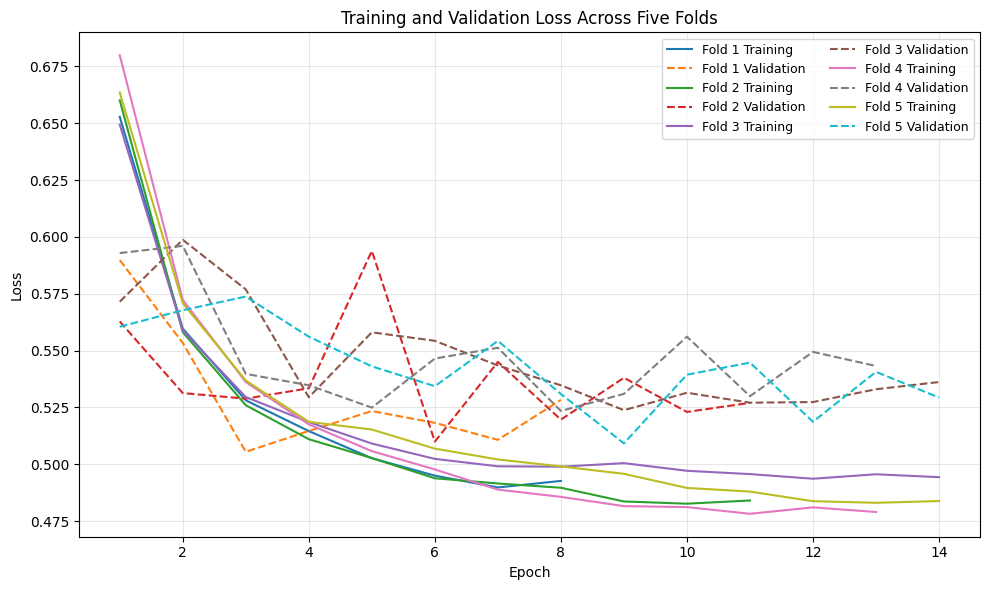

In [21]:
plt.figure(figsize=(10, 6))

for fold, fold_history in fold_histories.items():
    epochs = range(1, len(fold_history) + 1)

    plt.plot(
        epochs,
        fold_history["loss"],
        label=f"Fold {fold} Training"
    )

    plt.plot(
        epochs,
        fold_history["val_loss"],
        linestyle="--",
        label=f"Fold {fold} Validation"
    )

plt.title("Training and Validation Loss Across Five Folds")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(ncol=2, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

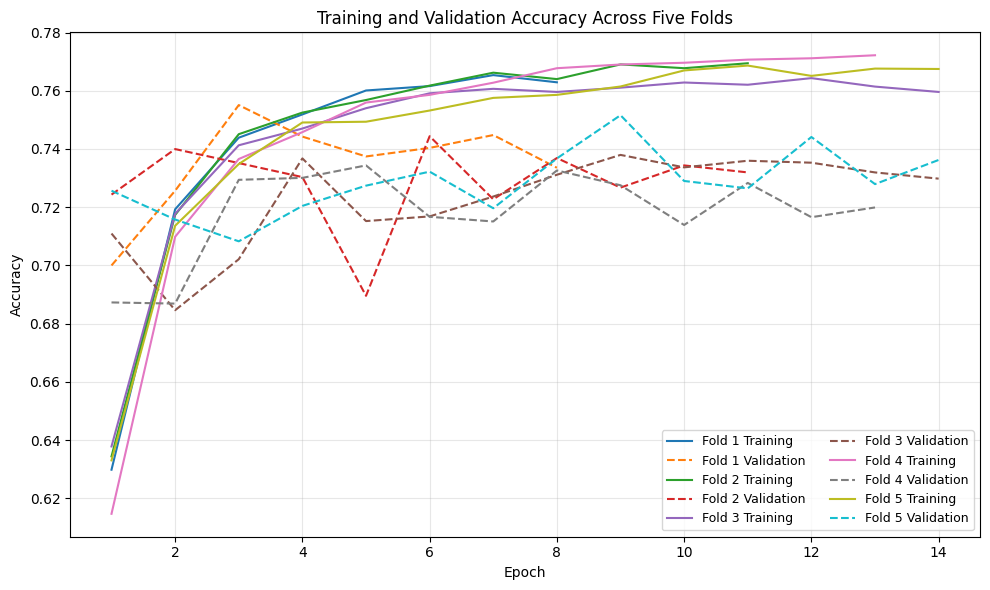

In [22]:
plt.figure(figsize=(10, 6))

for fold, fold_history in fold_histories.items():
    epochs = range(1, len(fold_history) + 1)

    plt.plot(
        epochs,
        fold_history["accuracy"],
        label=f"Fold {fold} Training"
    )

    plt.plot(
        epochs,
        fold_history["val_accuracy"],
        linestyle="--",
        label=f"Fold {fold} Validation"
    )

plt.title("Training and Validation Accuracy Across Five Folds")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(ncol=2, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

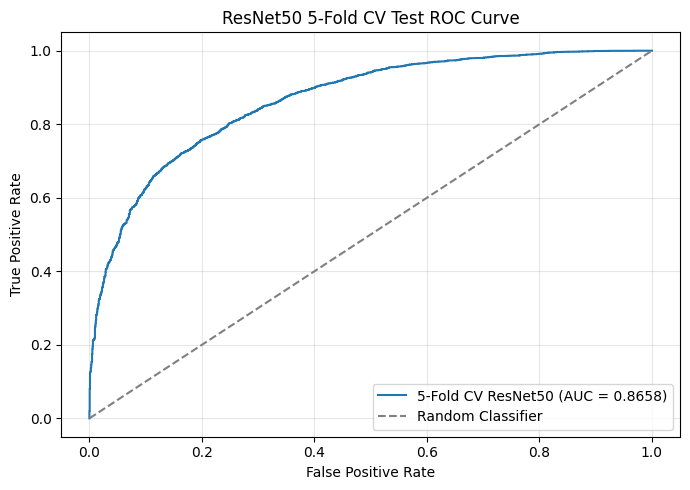

In [23]:
from sklearn.metrics import roc_curve

fpr_cv, tpr_cv, _ = roc_curve(
    true_test_labels,
    test_probabilities_cv
)

auc_cv = roc_auc_score(
    true_test_labels,
    test_probabilities_cv
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_cv,
    tpr_cv,
    label=f"5-Fold CV ResNet50 (AUC = {auc_cv:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.title("ResNet50 5-Fold CV Test ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

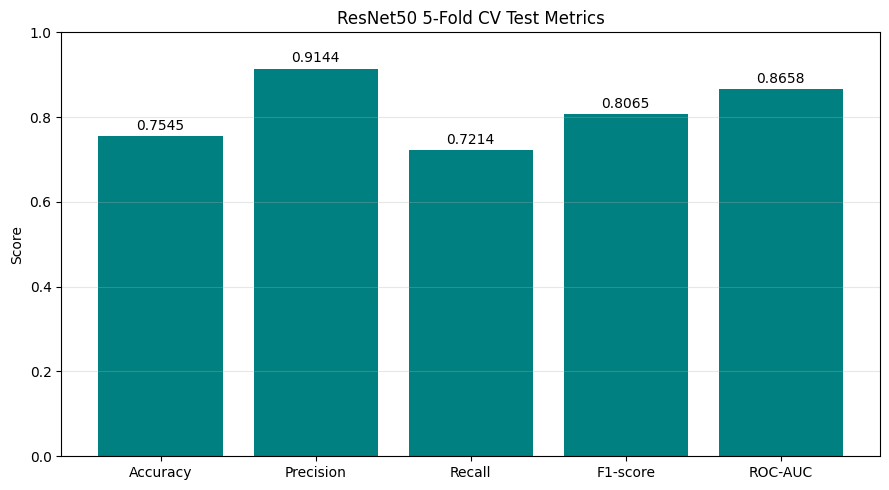

In [24]:
cv_metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

cv_metric_values = [
    accuracy_score(true_test_labels, test_predictions_cv),
    precision_score(true_test_labels, test_predictions_cv),
    recall_score(true_test_labels, test_predictions_cv),
    f1_score(true_test_labels, test_predictions_cv),
    roc_auc_score(true_test_labels, test_probabilities_cv)
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    cv_metric_names,
    cv_metric_values,
    color="teal"
)

plt.ylim(0, 1)
plt.title("ResNet50 5-Fold CV Test Metrics")
plt.ylabel("Score")

for bar, value in zip(bars, cv_metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.4f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

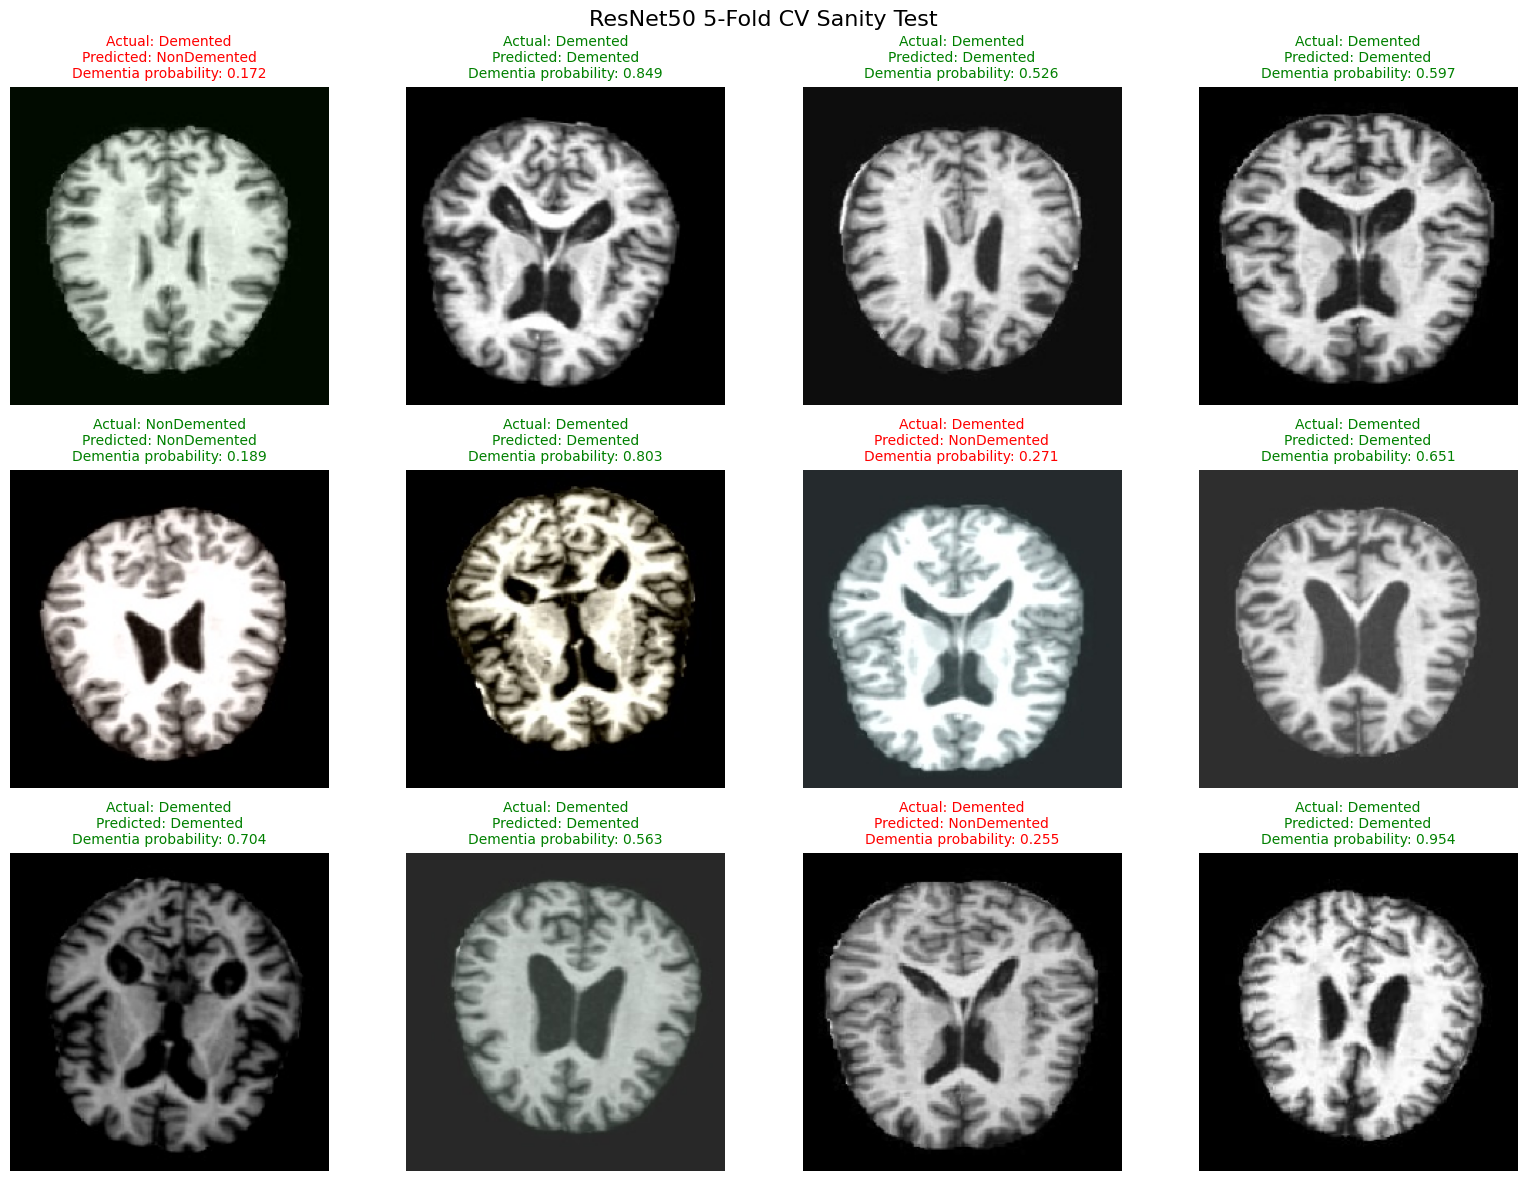

In [25]:
sample_indices = np.random.default_rng(SEED).choice(
    len(test_df),
    size=12,
    replace=False
)

plt.figure(figsize=(16, 12))

for position, index in enumerate(sample_indices, start=1):
    image = tf.keras.utils.load_img(
        test_df.iloc[index]["filepath"],
        target_size=IMG_SIZE
    )

    actual = true_test_labels[index]
    predicted = test_predictions_cv[index]
    probability = test_probabilities_cv[index]

    actual_name = (
        "Demented" if actual == 1
        else "NonDemented"
    )

    predicted_name = (
        "Demented" if predicted == 1
        else "NonDemented"
    )

    title_color = (
        "green" if actual == predicted
        else "red"
    )

    plt.subplot(3, 4, position)
    plt.imshow(image)
    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}\n"
        f"Dementia probability: {probability:.3f}",
        color=title_color,
        fontsize=10
    )
    plt.axis("off")

plt.suptitle(
    "ResNet50 5-Fold CV Sanity Test",
    fontsize=16
)

plt.tight_layout()
plt.show()